In [14]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import importlib
import pandas as pd
from universe import candidates, correlation, pca
from evaluation import plot
importlib.reload(correlation)
importlib.reload(candidates)

returns, tickers = candidates.load_data()
strat_sharpes, results = candidates.filter_strat_sharpes(tickers)
# asset_sharpes = candidates.filter_asset_sharpes(returns, tickers)

[*********************100%***********************]  28 of 28 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%******

In [16]:
import os

os.makedirs('universe/sharpes', exist_ok = True)
strat_sharpes.to_csv('universe/sharpes/clipped_strategy_sharpes.csv', index = False)
# asset_sharpes.to_csv('universe/sharpes/asset_sharpes.csv', index = False)

In [17]:
filtered_tickers = candidates.apply_sharpe_threshold(strat_sharpes)
tickers = filtered_tickers
returns = returns[filtered_tickers]

In [18]:
loadings, p_comp = pca.fit_pca(returns, tickers)
matrix = correlation.corr_matrix(returns)

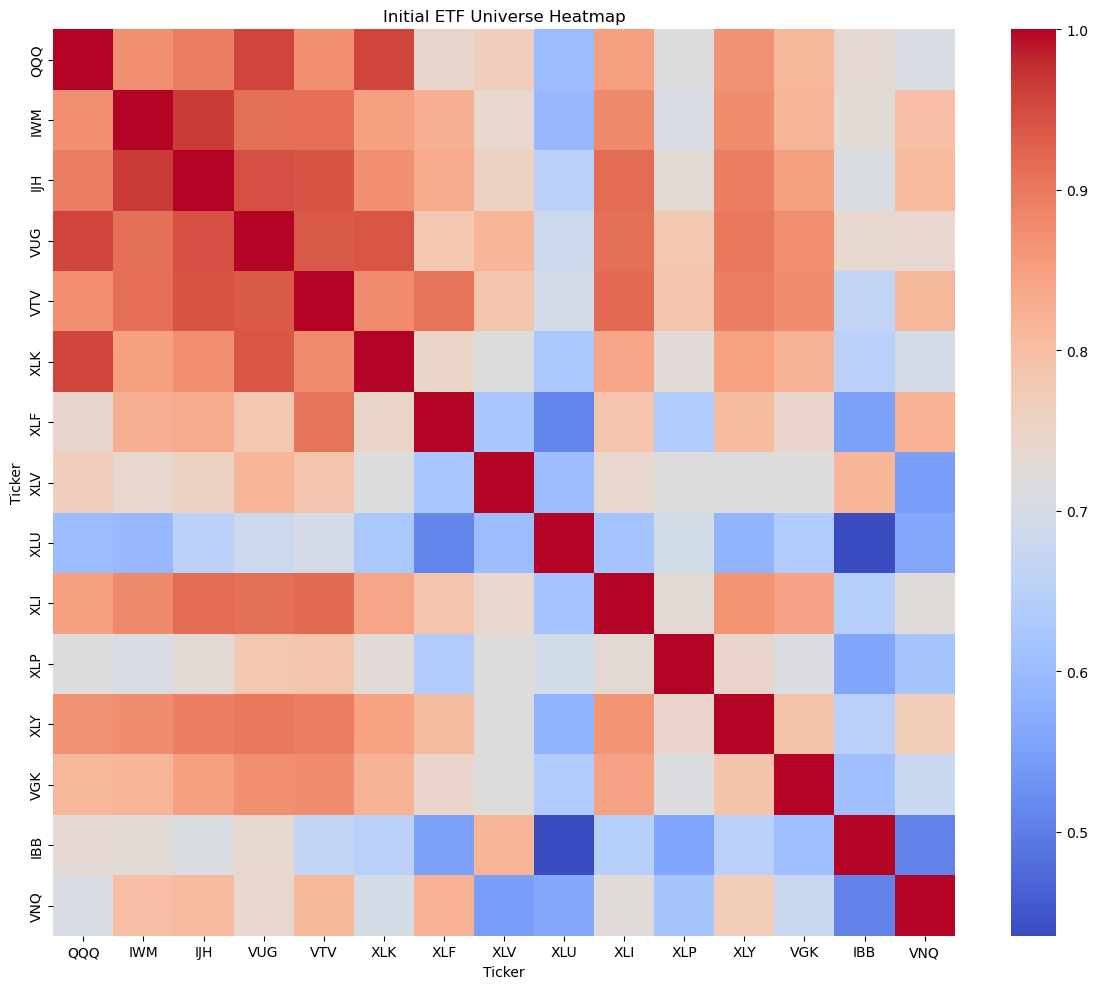

In [19]:
import os

heatmap = plot.plot_correlation_heatmap(matrix)
os.makedirs('results/universe_selection', exist_ok = True)
heatmap.savefig('results/universe_selection/correlation_heatmap.png')

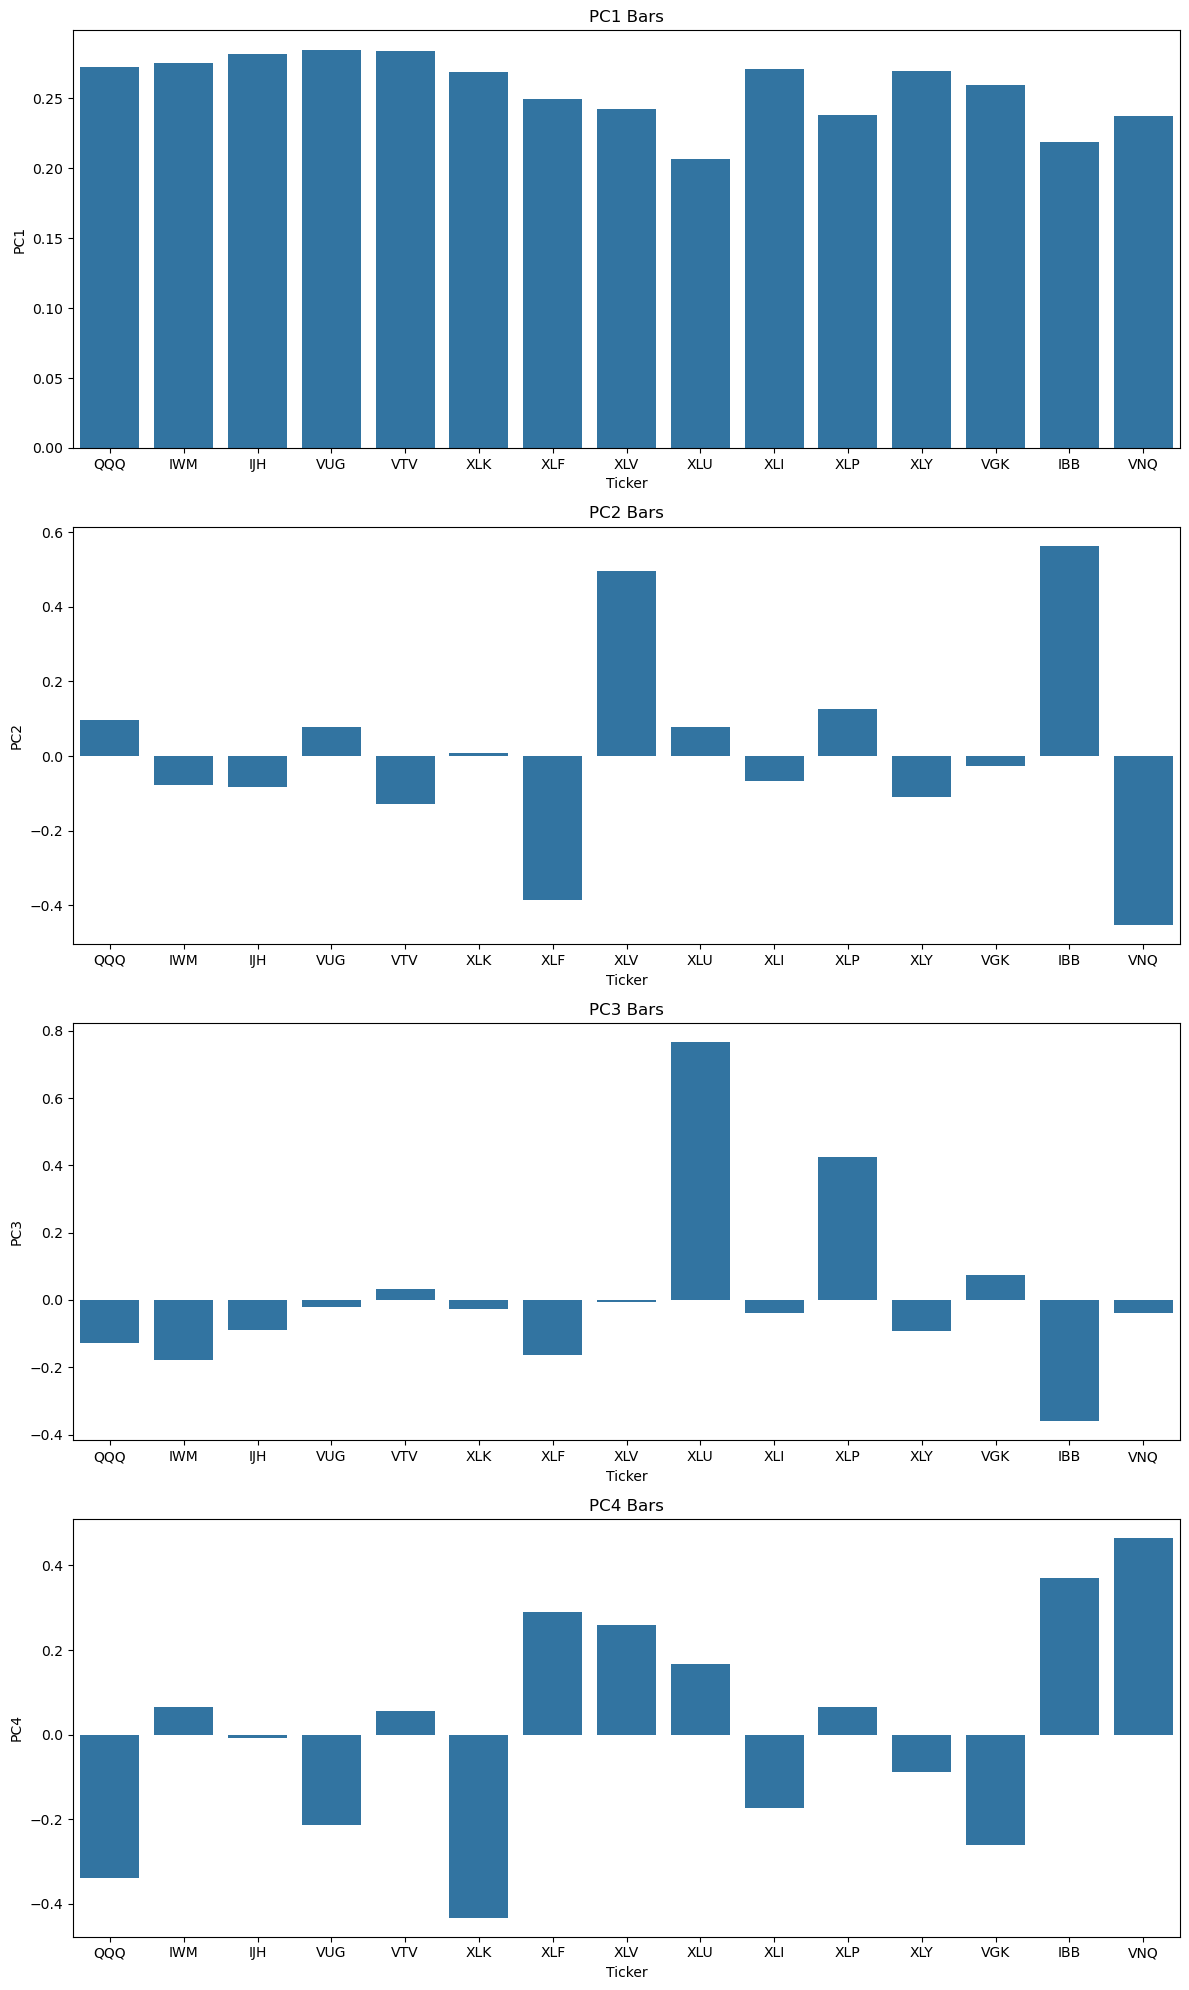

In [20]:
n_comp = pca.significant_components(p_comp)

pca_bars = plot.plot_pca_bars(loadings, n_comp)
os.makedirs('results/universe_selection', exist_ok = True)
pca_bars.savefig('results/universe_selection/pca_bars.png')

In [21]:
import pandas as pd

top_pcas = pca.top_pcas(loadings, n_comp)
top_pcas = correlation.correlation_check(top_pcas, matrix, loadings)
top_pcas.append('SPY')
top_pcas = pd.DataFrame(top_pcas)
top_pcas.to_csv('results/universe_selection/final_assets.csv', index = False)

checking: VUG and VTV
